In [1]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np  
import random
import bacco
from bacco.halo import virial_mass_converter, virial_concentration_converter
from scipy import interpolate
import copy

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import emcee
import corner

In [3]:
bacco.configuration.config['growth']['method']='reps'

In [4]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [19]:
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/scripts/train")
from GP_models import SMF_Model, fgas_Model

In [20]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

### Get Parameters

In [21]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))

rho_rec_or = np.log10(rho_rec_or)
ef_kin_or = np.log10(ef_kin_or)

wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [22]:
def pars(i, m500):

    arr = np.vstack( (m500, np.ones(len(m500)) * wind_en[i],\
                        np.ones(len(m500)) * wind_vel[i],\
                        np.ones(len(m500)) * rho_rec[i],\
                        np.ones(len(m500)) * sf_ts[i],\
                        np.ones(len(m500)) * ef_kin[i],\
                        np.ones(len(m500)) * ef_high[i],\
                        np.ones(len(m500)) * f_re[i])).T

    return arr

In [23]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

#### Load the MTNG

In [23]:
Nbins_fgas = 8

zoom_fgas = {}
for i in range(len(name_list)):
    zoom_fgas[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_{}_Nbins{:d}.npy".format(name_list[i], Nbins_fgas), allow_pickle=True)[0]

[autoreload of utils failed: Traceback (most recent call last):
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 455, in superreload
    module = reload(module)
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/importlib/__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'utils'
]


Text(0, 0.5, '$f_{gas}$')

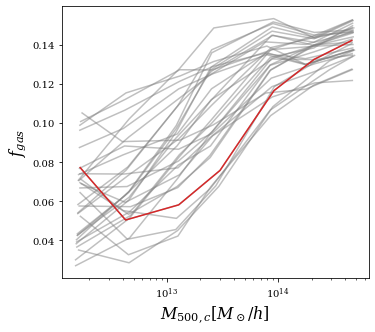

In [24]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('linear')

for i in range(len(name_list)):
    ax.plot(zoom_fgas[name_list[i]]['m500c'][0], zoom_fgas[name_list[i]]['f_gas'][0], color='gray', alpha=0.5)

ax.plot(zoom_fgas['fiducial']['m500c'][0], zoom_fgas['fiducial']['f_gas'][0], color='C3')

ax.set_xlabel(r"$M_{500,c} [M_\odot/h]$", fontsize=16)
ax.set_ylabel(r"$f_{gas}$", fontsize=16)

In [36]:
# Filter NaNs
for i in range(len(name_list)):
    mask = ~np.isnan(zoom_fgas[name_list[i]]['f_gas'][0]) & ~np.isnan(zoom_fgas[name_list[i]]['m500c'][0])
    
    zoom_fgas[name_list[i]]['f_gas'][0] = zoom_fgas[name_list[i]]['f_gas'][0][mask]
    zoom_fgas[name_list[i]]['m500c'][0] = zoom_fgas[name_list[i]]['m500c'][0][mask]

In [37]:
train_sel = np.argsort(dist)[::-1][:25]
test_sel = list(set(range(31)) - set(train_sel))

In [38]:
#del smf_global, arr_global
pars_global = pars(train_sel[0], np.log10(zoom_fgas[name_list[train_sel[0]]]['m500c'][0]) )
fgas_global = zoom_fgas[name_list[train_sel[0]]]['f_gas'][0]

for i in range(len(train_sel)):
    m500c = np.log10(zoom_fgas[name_list[train_sel[i]]]['m500c'][0])

    arr = pars(train_sel[i], m500c)

    pars_global = np.vstack((pars_global, arr))

    fgas_global = np.hstack((fgas_global, zoom_fgas[name_list[train_sel[i]]]['f_gas'][0]))

In [40]:
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(fgas_global, dtype=torch.float)

In [103]:
class fgas_Model(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(fgas_Model, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=8))

    def initialize(self):
        # reset constant mean to something reasonable
        self.mean_module.constant.data.normal_(0, 0.1)

        # lengthscales (ARD) :
        # initialize in log-space so we get spread over ~[0.3, 3] in standardized units
        with torch.no_grad():
            ls = 0.5 + torch.rand_like(self.covar_module.base_kernel.lengthscale)
            self.covar_module.base_kernel.lengthscale.copy_(ls)

        # reset outputscale
        self.covar_module.outputscale = 1.0

        # reset likelihood noise to moderate value
        self.likelihood.noise = 2e-4

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [104]:

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-5))
model = fgas_Model(train_x, train_y, likelihood)

In [105]:
torch.set_num_threads(8)

In [106]:
n_restarts = 200
steps_per_restart = 50

best_state = None
best_loss = float('inf')

for r in range(n_restarts):
    print(f"\n=== Restart {r+1}/{n_restarts} ===")
    model.initialize()

    # Find optimal model_fgas hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(steps_per_restart):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -torch.sum(mll(output, train_y))
        loss.backward()
        optimizer.step()

    # compute final loss for this restart
    with torch.no_grad():
        final_output = model(train_x)
        final_loss = float(-mll(final_output, train_y))

    print(f"Final loss restart {r+1}: {final_loss:.4f}")

    # store best
    if final_loss < best_loss:
        best_loss = final_loss
        best_state = {
            'model': copy.deepcopy(model.state_dict()),
            'likelihood': copy.deepcopy(likelihood.state_dict()),
        }

# ---- restore best ----
model.load_state_dict(best_state['model'])
likelihood.load_state_dict(best_state['likelihood'])


=== Restart 1/200 ===
Final loss restart 1: -0.8675

=== Restart 2/200 ===
Final loss restart 2: -1.2629

=== Restart 3/200 ===
Final loss restart 3: -1.5776

=== Restart 4/200 ===
Final loss restart 4: -1.8245

=== Restart 5/200 ===
Final loss restart 5: -2.0173

=== Restart 6/200 ===
Final loss restart 6: -2.1674

=== Restart 7/200 ===
Final loss restart 7: -2.2842

=== Restart 8/200 ===
Final loss restart 8: -2.3744

=== Restart 9/200 ===
Final loss restart 9: -2.4427

=== Restart 10/200 ===
Final loss restart 10: -2.4948

=== Restart 11/200 ===
Final loss restart 11: -2.5350

=== Restart 12/200 ===
Final loss restart 12: -2.5667

=== Restart 13/200 ===
Final loss restart 13: -2.5929

=== Restart 14/200 ===
Final loss restart 14: -2.6154

=== Restart 15/200 ===
Final loss restart 15: -2.6368

=== Restart 16/200 ===
Final loss restart 16: -2.6571

=== Restart 17/200 ===
Final loss restart 17: -2.6779

=== Restart 18/200 ===
Final loss restart 18: -2.6995

=== Restart 19/200 ===
Fina

<All keys matched successfully>

In [129]:
# ### Load GP

# model = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_fgas.pth")
# likelihood = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_fgas.pth")

# # Get into evaluation (predictive posterior) mode
# model_fgas.eval()
# likelihood_fgas.eval()

/tmp/ipykernel_269926/2559135750.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-06)
  )
)

In [130]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

tensor([[ 2.7572, 19.0905, 16.3702, 22.6700, 39.6111, 39.0296, 39.7572, 39.7575]],
       grad_fn=<SoftplusBackward0>)
tensor(0.8799, grad_fn=<SoftplusBackward0>)
tensor([0.0129], grad_fn=<SqrtBackward0>)


In [131]:
model.eval()
likelihood.eval()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-05)
  )
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


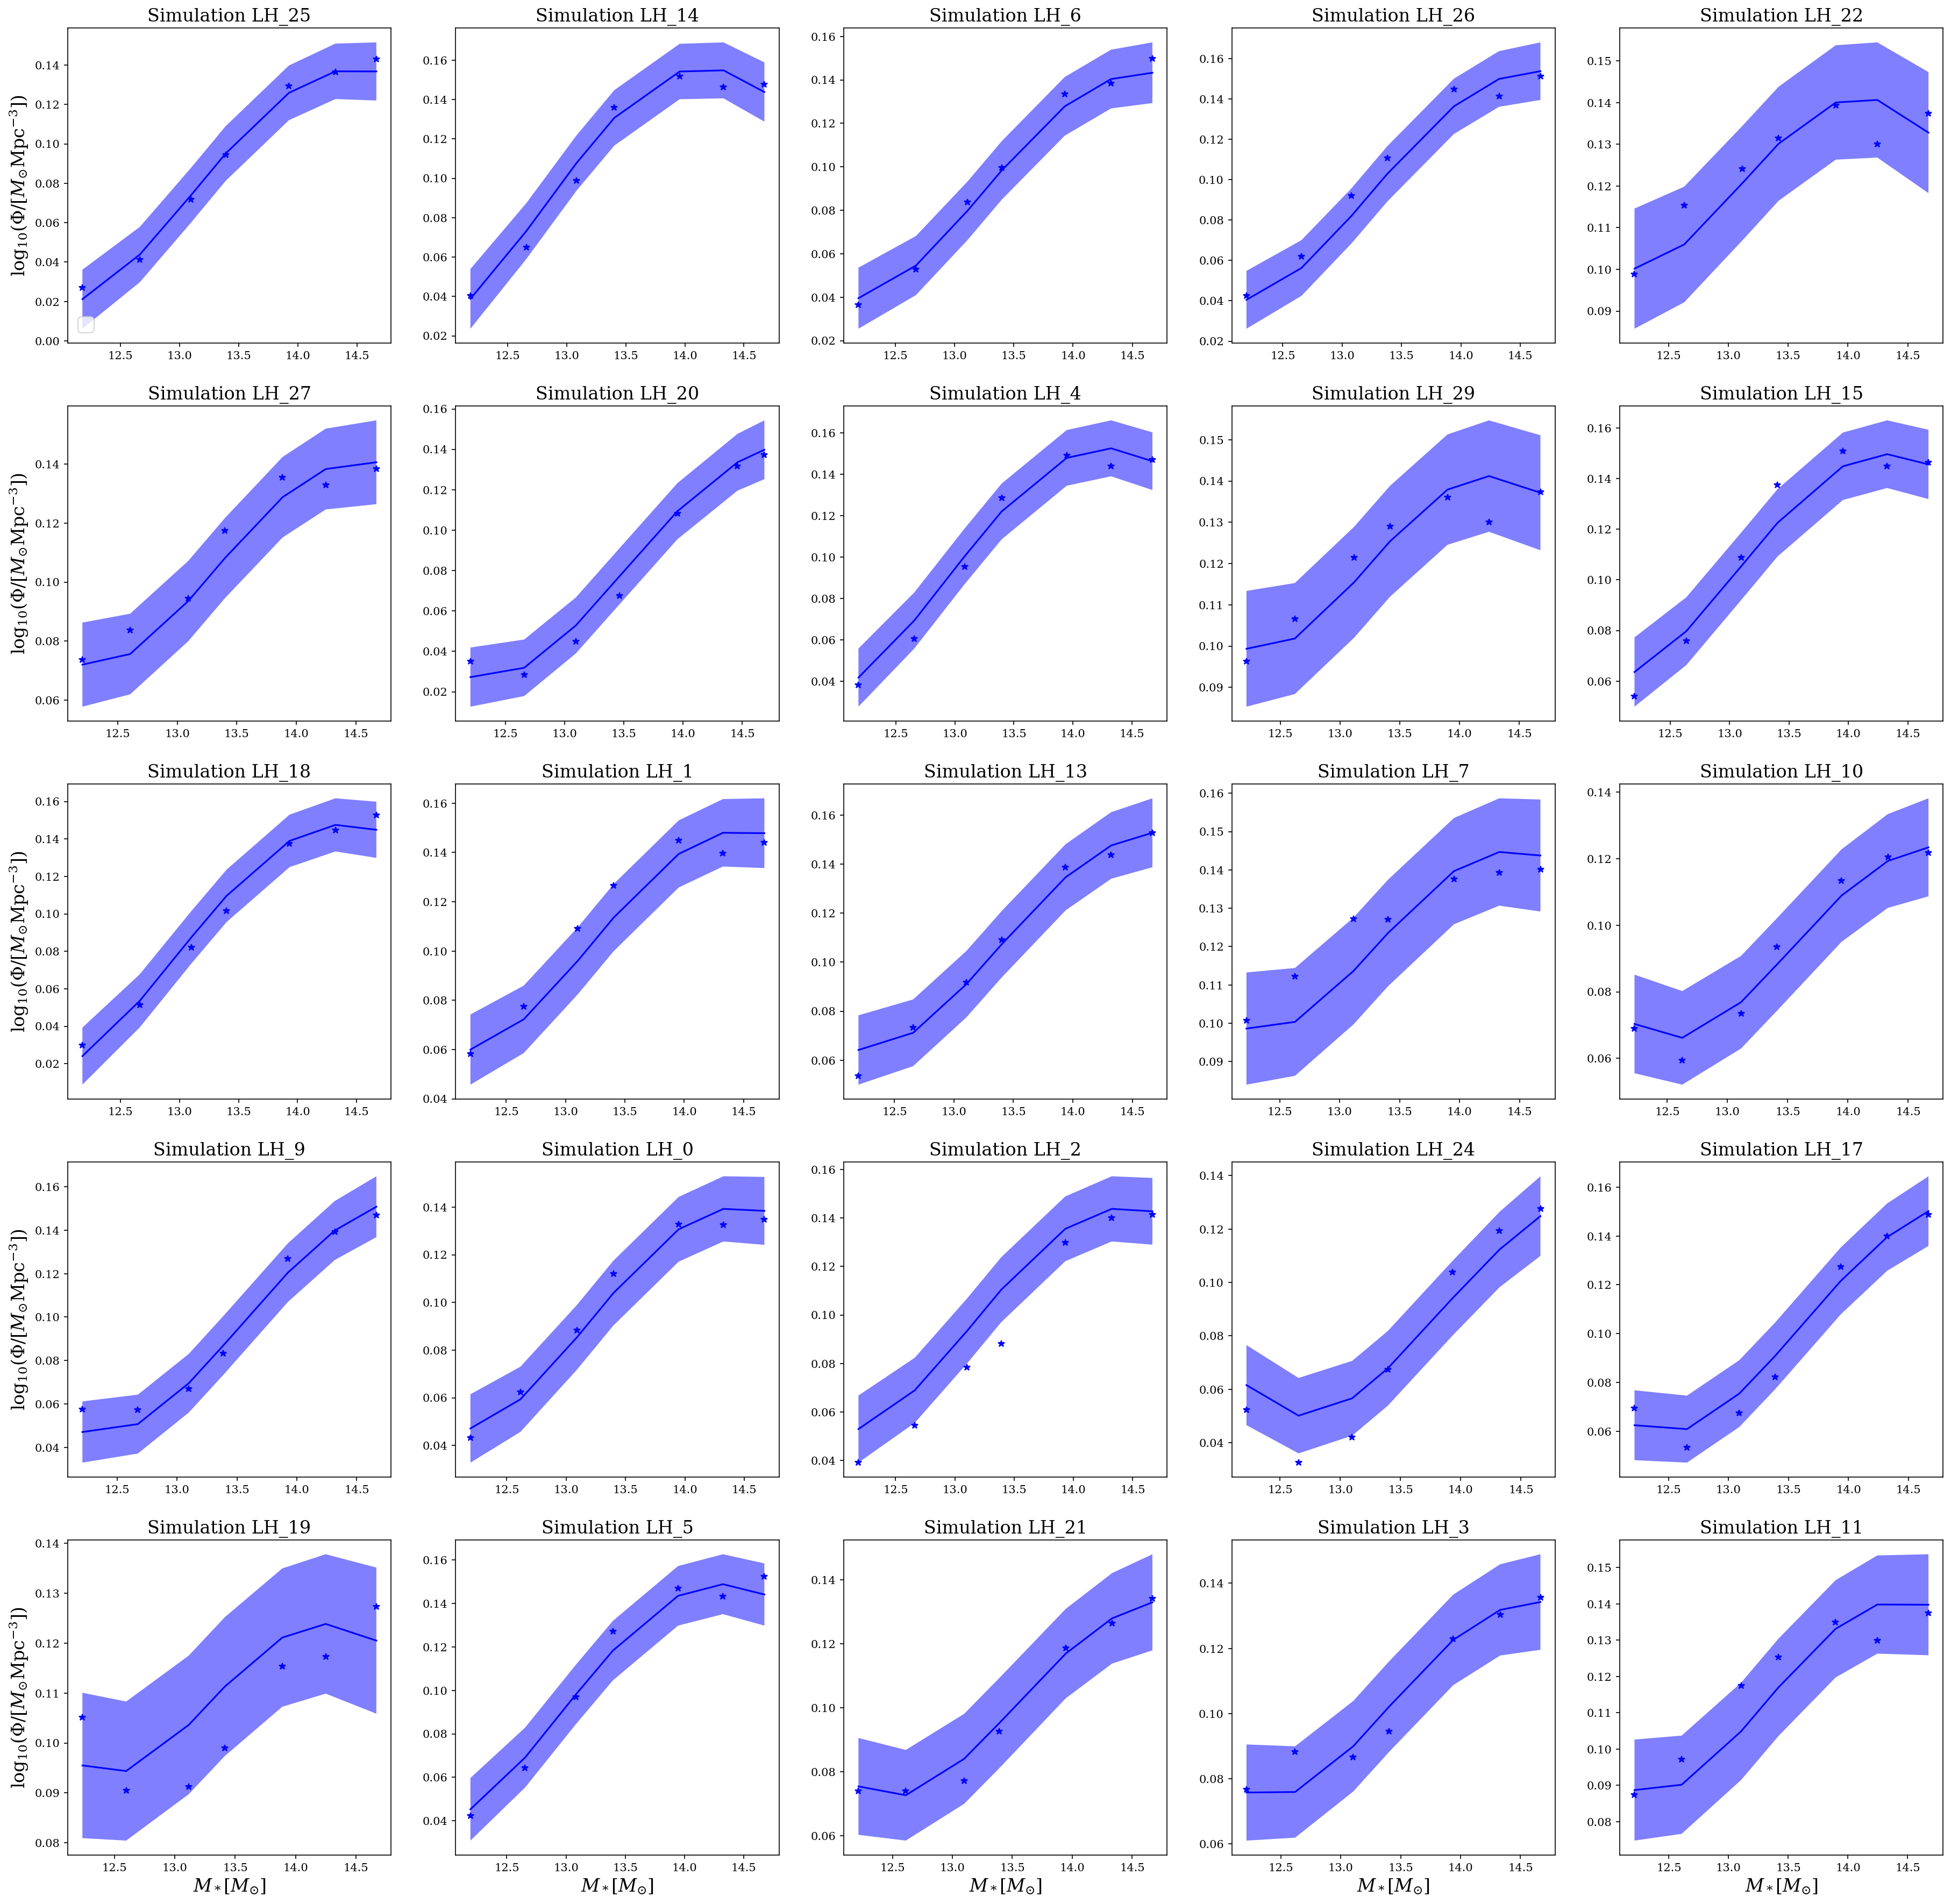

In [132]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(5, 5, figsize=(30, 30), dpi=150)

    for i in range(5):
        for j in range(5):
            test_x = torch.asarray(pars(train_sel[5*i+j], np.log10(zoom_fgas[name_list[train_sel[5*i+j]]]['m500c'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))

            ax[i,j].set_title('Simulation {:s}'.format(name_list[train_sel[5*i+j]]), fontsize=16)

            if j==0:
                ax[i,j].set_ylabel('$\log_{10}(\Phi/[M_{\odot}\mathrm{Mpc}^{-3}])$', fontsize=16)
            if i==4:
                ax[i,j].set_xlabel('$M_*[M_{\odot}]$', fontsize=16)

            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot training data as black stars
            ax[i,j].plot(np.log10(zoom_fgas[name_list[train_sel[5*i+j]]]['m500c'][0]), zoom_fgas[name_list[train_sel[5*i+j]]]['f_gas'][0], 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

ax[0,0].legend(loc='lower left', fontsize=18)

In [8]:
# Popesso et al
m500_pp = np.asarray([12.3,12.6,12.9,13.1,13.3,13.6,14.0,14.5])
fgas_pp = np.asarray([0.011,0.028,0.019,0.035,0.033,0.039,0.052,0.104])
err_pp = np.asarray([0.006,0.013,0.011,0.014,0.013,0.013,0.014,0.016])

# Kugel et al
m500_kugel = np.asarray([13.89, 14.06, 14.23, 14.40, 14.57, 14.74, 14.91])
fgas_kugel = np.asarray([0.083, 0.094, 0.105, 0.115, 0.130, 0.130, 0.139])
err_kugel = np.asarray([0.002, 0.003, 0.005, 0.008, 0.002, 0.002, 0.003])

In [9]:
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/scripts/train")
from GP_models import SMF_Model, fgas_Model

In [10]:
models = {}
likes = {}
for i in range(10):
    models[i] = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/scripts/cross-validation/best_models_k10_nbins10/full_model_fgas_{:d}.pth".format(i))
    likes[i] = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/scripts/cross-validation/best_models_k10_nbins10/full_likelihood_fgas_{:d}.pth".format(i))


/tmp/ipykernel_422423/1599876245.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models[i] = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/scripts/cross-validatio

In [11]:
print(models[0].covar_module.base_kernel.lengthscale)
print(models[0].covar_module.outputscale)
print(torch.sqrt(models[0].likelihood.noise_covar.noise))

extra_noise = models[0].likelihood.second_noise_covar.noise
print(f"Learned additional noise (variance): {extra_noise.item():.6f}")
print(f"Learned additional noise (std): {extra_noise.item()**0.5:.6f}")

tensor([[ 1.2715,  7.3747,  5.9069, 11.1421, 17.8334, 26.5149, 64.5853, 65.1423]],
       grad_fn=<SoftplusBackward0>)
tensor(0.0192, grad_fn=<SoftplusBackward0>)
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0148, 0.0174, 0.0144, 0.0147])
Learned additional noise (variance): 0.000100
Learned additional noise (std): 0.010000


In [13]:
model_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_fgas.pth")
likelihood_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_fgas.pth")

model_fgas.eval()
likelihood_fgas.eval()

/tmp/ipykernel_422423/3053673088.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_

FixedNoiseGaussianLikelihood(
  (noise_covar): FixedGaussianNoise()
  (second_noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [14]:
print(model_fgas.covar_module.base_kernel.lengthscale)
print(model_fgas.covar_module.outputscale)
print(torch.sqrt(model_fgas.likelihood.noise_covar.noise))

extra_noise = model_fgas.likelihood.second_noise_covar.noise
print(f"Learned additional noise (variance): {extra_noise.item():.6f}")
print(f"Learned additional noise (std): {extra_noise.item()**0.5:.6f}")

tensor([[1.4978, 5.2787, 4.7770, 5.5289, 7.0951, 6.1618, 7.4218, 7.8467]],
       grad_fn=<SoftplusBackward0>)
tensor(0.0058, grad_fn=<SoftplusBackward0>)
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100])
Learned additional noise (variance): 0.000100
Learned additional noise (std): 0.010000


In [15]:
def get_theta_1p_vars(param_num, mstar, nvars):
    fid_theta = np.array([wind_en[30], wind_vel[30], rho_rec[30], sf_ts[30], ef_kin[30], ef_high[30], f_re[30]])

    theta_1p_vars = {}

    delta = 2 / nvars
    for i in range(nvars+1):
        par_array = np.copy(fid_theta)
        par_array[param_num] += (i - nvars//2) * delta
        theta_1p_vars[i] = np.vstack( ( mstar, np.ones(len(mstar)) * par_array[0],\
                                        np.ones(len(mstar)) * par_array[1],\
                                        np.ones(len(mstar)) * par_array[2],\
                                        np.ones(len(mstar)) * par_array[3],\
                                        np.ones(len(mstar)) * par_array[4],\
                                        np.ones(len(mstar)) * par_array[5],\
                                        np.ones(len(mstar)) * par_array[6])).T

    return theta_1p_vars

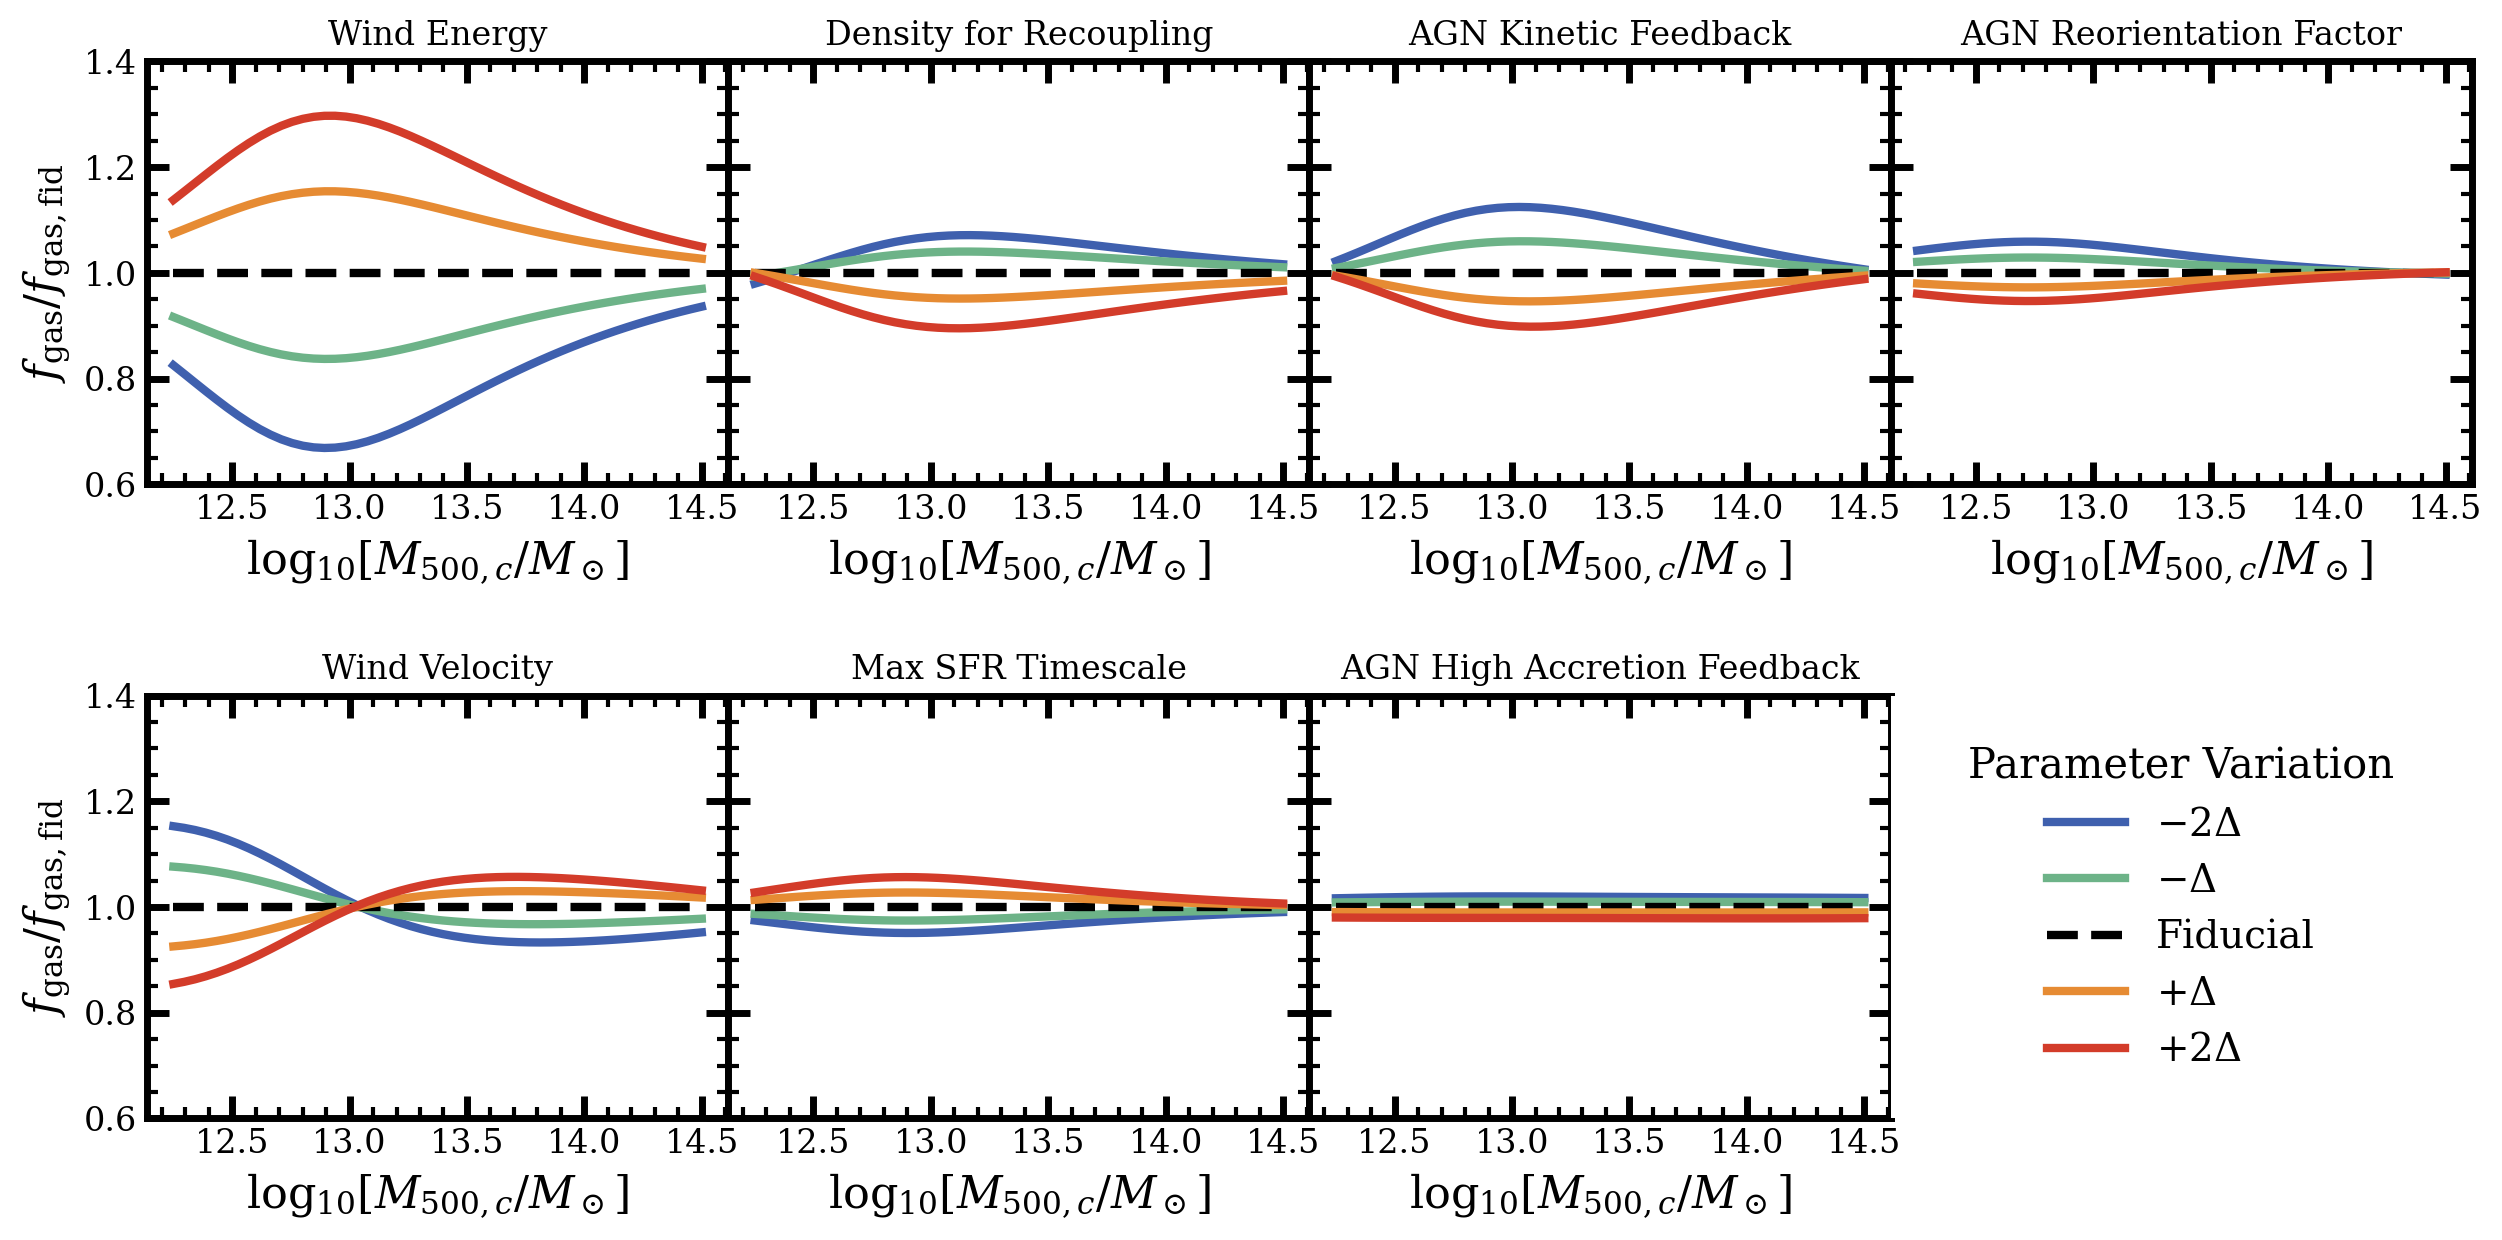

In [25]:
fig, ax = plt.subplots(2, 4, dpi=200, sharey=False, figsize=(15,7))

# Paul Tol's discrete rainbow scheme - selecting 4 well-separated colors
# for the -2Δ, -Δ, +Δ, +2Δ variations (Fiducial stays black)
tol_rainbow = ['#3F60AE', '#6DB388', '#E68B33', '#D33C2A']  # blue, green, orange, red

mstar_test = np.linspace(12.25,14.5,50)
names = ['Wind Energy', 'Wind Velocity', 'Density for Recoupling', 'Max SFR Timescale', 'AGN Kinetic Feedback', 'AGN High Accretion Feedback', 'AGN Reorientation Factor']


for ax_i in np.ndarray.flatten(ax):
    # ax_i.set_ylim(0.65,1.35)
    # Thicker plot edges
    for spine in ax_i.spines.values():
        spine.set_linewidth(2.5)

    # Major and minor ticks
    ax_i.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', right=True, top=True)
    ax_i.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', right=True, top=True)
    ax_i.minorticks_on()

labels=['$-2\Delta$', '$-\Delta$', 'Fiducial', '$+\Delta$', '$+2\Delta$']

# Map n=0,1,3,4 to tol_rainbow indices 0,1,2,3
color_map = {0: tol_rainbow[0], 1: tol_rainbow[1], 3: tol_rainbow[2], 4: tol_rainbow[3]}

for i in range(2):
    for j in range(4):
        ax[i,j].set_ylim(0.6,1.4)
        if 2*j+i >= 7:
            ax[i,j].set_xticks([])
            ax[i,j].set_yticks([])
            for spine in ax[i,j].spines.values():
                spine.set_visible(False)
            ax[i,j].minorticks_off()
            continue

        ax[i,j].set_title(names[2*j+i])
        ax[i,j].set_xlabel(r"$\log_{10}[M_{500,c}/M_\odot]$", fontsize=16)
        theta_vars = get_theta_1p_vars(2*j+i, mstar_test, 5)

        mu_fid, var_fid = model_fgas(torch.asarray(theta_vars[2], dtype=torch.float)).mean.detach().numpy(), model_fgas(torch.asarray(theta_vars[2], dtype=torch.float)).variance.detach().numpy()

        for n in range(5):
            mu_pred, var = model_fgas(torch.asarray(theta_vars[n], dtype=torch.float)).mean.detach().numpy(), model_fgas(torch.asarray(theta_vars[n], dtype=torch.float)).variance.detach().numpy()
            if n == 2:
                ax[i,j].plot(mstar_test, mu_pred / mu_fid, label="Fiducial", ls='--', color='k', lw=3)
            else:
                ax[i,j].plot(mstar_test, mu_pred / mu_fid, color=color_map[n], label=labels[n], lw=3)

for i in range(3):
    ax[0,i+1].set_yticklabels([])
    ax[1,i+1].set_yticklabels([])

# Y-axis labels on the leftmost column
ax[0,0].set_ylabel(r"$f_\mathrm{gas} / f_\mathrm{gas, fid}$", fontsize=16)
ax[1,0].set_ylabel(r"$f_\mathrm{gas} / f_\mathrm{gas, fid}$", fontsize=16)

# Legend in the empty panel
handles, leg_labels = ax[0,0].get_legend_handles_labels()
order = [0, 1, 2, 3, 4]
handles = [handles[k] for k in order]
leg_labels = [leg_labels[k] for k in order]

ax[1,3].legend(handles, leg_labels, loc='center', fontsize=14, frameon=False, title='Parameter Variation', title_fontsize=15)

plt.subplots_adjust(wspace=0.0, hspace=0.5)
plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/fgas_parameter_variation.pdf", bbox_inches='tight')